### Self Attention 구현
![Self Attention](https://github.com/chulminkw/transformer_class/blob/main/images/self_attention_equation.png?raw=true)

### 학습 파라미터 없이 단일 토큰에 Self Attention 적용 하기
#### 단일 토큰의 attention score 계산하기(attention score = q @ K.T)
![단일 토큰 attention score](https://github.com/chulminkw/transformer_class/blob/main/images/single_token_attention_score.png?raw=true)

In [1]:
import torch
import torch.nn.functional as F

tokens = ["The", "cat", "sat", "on", "the", "mat"]
# 테스트용 값으로 token embeddings tensor 값 생성.
token_embeddings = torch.tensor([
    [1.0, 0.0, 0.0],   # The
    [1.0, 1.0, 0.0],   # cat
    [0.5, 1.0, 0.5],   # sat
    [0.0, 1.0, 1.0],   # on
    [1.0, 0.0, 0.0],   # the
    [1.0, 0.5, 1.0],   # mat
])  # shape: (6, 3)


In [2]:
# token 'cat'과 다른 토큰간의 attention score 계산
cat_query = token_embeddings[1]  # [1.0, 1.0, 0.0]
keys = token_embeddings.clone()

cat_attn_scores = cat_query @ keys.T  # shape: (6,) cat_query @ token_embeddings.T 무방
# dot("The")   = [1,0,0] · [1,1,0] = 1
# dot("cat")   = [1,1,0] · [1,1,0] = 2
# dot("sat")   = [0.5,1,0.5] · [1,1,0] = 0.5+1+0 = 1.5
# dot("on")    = [0,1,1] · [1,1,0] = 1
# dot("the")   = [1,0,0] · [1,1,0] = 1
# dot("mat")   = [1,0.5,1] · [1,1,0] = 1 + 0.5 + 0 = 1.5
print(f"cat_attn_scores:{cat_attn_scores}, ")

cat_attn_scores:tensor([1.0000, 2.0000, 1.5000, 1.0000, 1.0000, 1.5000]), 


#### 단일 토큰에 대한 attention weights 계산하기
* attention score 값에 대해서 softmax로 정규화 적용(전체 sum이 1이 되도록 적용). embedding 차원 개수로의 scale 작업은 일단 수행하지 않음
![단일 토큰 attention score](https://github.com/chulminkw/transformer_class/blob/main/images/single_token_att_weights.png?raw=true)

In [3]:
# attention score 값에 대해서 softmax로 정규화 적용(전체 sum이 1이 되도록 적용). embedding 차원 개수로의 scale 작업은 일단 수행하지 않음
# 1차원에 대한 softmax 적용이므로 dim이 불필요 할 수도 있지만, 함수에서 명시적으로 설정할 것을 요구
cat_attn_weights = F.softmax(cat_attn_scores, dim=-1)
print(f"cat_attn_weights:{cat_attn_weights}")

cat_attn_weights:tensor([0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829])


### 단일 토큰의 context vector 값 구하기
* 개별 단어의 Attention Weights를 반영하여 문장 문맥 의미가 적용된 단어 만들기
![단일 토큰 context vector](https://github.com/chulminkw/transformer_class/blob/main/images/single_token_attn_weights_applied.png?raw=true)

In [4]:
cat_query = token_embeddings[1]  # [1.0, 1.0, 0.0]
keys = token_embeddings.clone()
# cat token의 context vector를 구하기 위한 values
values = token_embeddings.clone()

cat_attn_weight = F.softmax(cat_query @ keys.T, dim=-1)
print(f"cat_attn_weight:{cat_attn_weight}")

## 'cat' token의 context vector 값 구하기
cat_context_vec = cat_attn_weight @ values
print(f"cat_context_vec:{cat_context_vec}")

'''
token_embeddings = torch.tensor([
    [1.0, 0.0, 0.0],   # The
    [1.0, 1.0, 0.0],   # cat
    [0.5, 1.0, 0.5],   # sat
    [0.0, 1.0, 1.0],   # on
    [1.0, 0.0, 0.0],   # the
    [1.0, 0.5, 1.0],   # mat
])

0.7976 = 0.1109 * 1.0 + 0.3015*1.0 + 0.1829*0.5 + 0.1109*0.0 + 0.1109*1.0 + 0.1829*1.0
0.6867 = 0.1108 * 0.0 + 0.3015*1.0 + 0.1829*1.0 + 0.1109*1.0 + 0.1109*0.0 + 0.1829*0.5
0.3852 = 0.1108 * 0.0 + 0.3015*0.0 + 0.1829*0.5 + 0.1109*1.0 + 0.1109*0.0 + 0.1829*1.0
'''

cat_attn_weight:tensor([0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829])
cat_context_vec:tensor([0.7976, 0.6867, 0.3852])


'\ntoken_embeddings = torch.tensor([\n    [1.0, 0.0, 0.0],   # The\n    [1.0, 1.0, 0.0],   # cat\n    [0.5, 1.0, 0.5],   # sat\n    [0.0, 1.0, 1.0],   # on\n    [1.0, 0.0, 0.0],   # the\n    [1.0, 0.5, 1.0],   # mat\n])\n\n0.7976 = 0.1109 * 1.0 + 0.3015*1.0 + 0.1829*0.5 + 0.1109*0.0 + 0.1109*1.0 + 0.1829*1.0\n0.6867 = 0.1108 * 0.0 + 0.3015*1.0 + 0.1829*1.0 + 0.1109*1.0 + 0.1109*0.0 + 0.1829*0.5\n0.3852 = 0.1108 * 0.0 + 0.3015*0.0 + 0.1829*0.5 + 0.1109*1.0 + 0.1109*0.0 + 0.1829*1.0\n'

In [5]:
# 전체 query token들의 attention weights를 simulation하기 위해서 개별 query token들을 loop 방식으로 차례로 q @ K.T 적용
attn_weights_matrix_temp = torch.empty(token_embeddings.shape[0], token_embeddings.shape[0])
print(attn_weights_matrix_temp.shape)

queries = token_embeddings.clone() #(6,3)
keys = token_embeddings.clone() #(6,3)

# 전체 token들을 순차적으로 loop를 돌면서 attention_weight를 구함.
for idx, query_token in enumerate(queries):
    attn_weight = F.softmax(query_token @ keys.T, dim=-1)
    print(f"token {tokens[idx]}: {query_token}'s attn_weight: {attn_weight}")
    attn_weights_matrix_temp[idx] = attn_weight

print(f"\nattn_weights_matrix_temp:\n{attn_weights_matrix_temp}")

torch.Size([6, 6])
token The: tensor([1., 0., 0.])'s attn_weight: tensor([0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010])
token cat: tensor([1., 1., 0.])'s attn_weight: tensor([0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829])
token sat: tensor([0.5000, 1.0000, 0.5000])'s attn_weight: tensor([0.0777, 0.2112, 0.2112, 0.2112, 0.0777, 0.2112])
token on: tensor([0., 1., 1.])'s attn_weight: tensor([0.0475, 0.1290, 0.2127, 0.3507, 0.0475, 0.2127])
token the: tensor([1., 0., 0.])'s attn_weight: tensor([0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010])
token mat: tensor([1.0000, 0.5000, 1.0000])'s attn_weight: tensor([0.0958, 0.1580, 0.1580, 0.1580, 0.0958, 0.3344])

attn_weights_matrix_temp:
tensor([[0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829],
        [0.0777, 0.2112, 0.2112, 0.2112, 0.0777, 0.2112],
        [0.0475, 0.1290, 0.2127, 0.3507, 0.0475, 0.2127],
        [0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.0958, 

### 문장내 모든 token 들의 attention weights 구하기
![attention weights](https://github.com/chulminkw/transformer_class/blob/main/images/all_token_attention_score.png?raw=true)
![attention weights](https://github.com/chulminkw/transformer_class/blob/main/images/all_token_attention_weights.png?raw=true)
* Q = token_embeddings, K = token_embeddings 일때
* Softmax(Q @ K.T) 로 문장내 모든 token들의 attention weights 계산(정방 행렬이 됨)
* 생성된 attention weights의 shape는 (문장 sequence length, 문장 sequence length)가 됨.
* 즉 위의 token_embeddings는 6개의 token들(문장 sequence length가 6)로 구성되어 있으므로 attention weights의 shape는 (6, 6)

In [6]:
# matrix multiplication으로 모든 token들의 attention weight를 matrix 형태로 구하기
queries = token_embeddings.clone()
keys = token_embeddings.clone()

# attention score 계산
attn_scores = queries @ keys.T
# softmax 정규화 적용. dim = -1= 맨 마지막 차원
attn_weights = F.softmax(attn_scores, dim=-1)

print(f"attn_scores:\n{attn_scores}")
print(f"attn_weights:\n{attn_weights}")

attn_scores:
tensor([[1.0000, 1.0000, 0.5000, 0.0000, 1.0000, 1.0000],
        [1.0000, 2.0000, 1.5000, 1.0000, 1.0000, 1.5000],
        [0.5000, 1.5000, 1.5000, 1.5000, 0.5000, 1.5000],
        [0.0000, 1.0000, 1.5000, 2.0000, 0.0000, 1.5000],
        [1.0000, 1.0000, 0.5000, 0.0000, 1.0000, 1.0000],
        [1.0000, 1.5000, 1.5000, 1.5000, 1.0000, 2.2500]])
attn_weights:
tensor([[0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829],
        [0.0777, 0.2112, 0.2112, 0.2112, 0.0777, 0.2112],
        [0.0475, 0.1290, 0.2127, 0.3507, 0.0475, 0.2127],
        [0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.0958, 0.1580, 0.1580, 0.1580, 0.0958, 0.3344]])


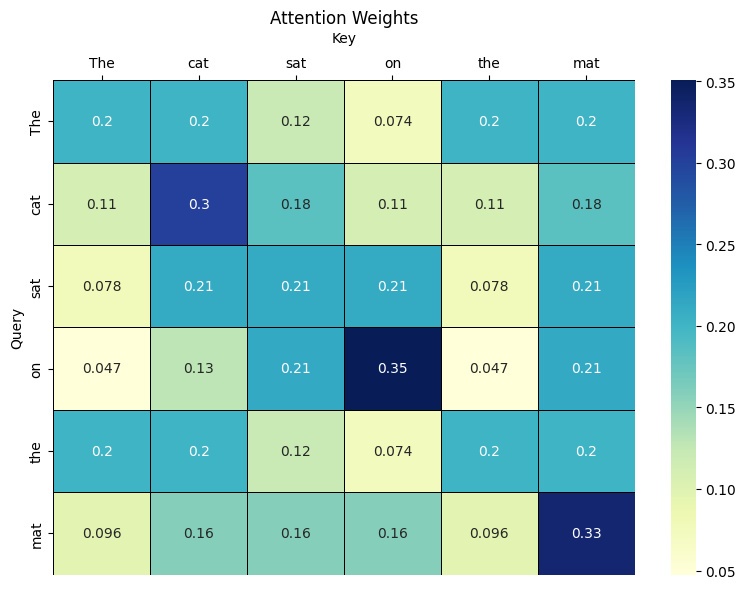

In [7]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

tokens = ["The", "cat", "sat", "on", "the", "mat"]

plt.figure(figsize=(8, 6))
# 위에서 계산한 attn_weights를 numpy()를 변환하여 seaborn의 heatmap으로 시각화
ax = sns.heatmap(attn_weights.detach().numpy(), annot=True,
                 cmap="YlGnBu", xticklabels=tokens, yticklabels=tokens,
                linewidths=0.5, linecolor='black')

# Title and labels
plt.title("Attention Weights")
ax.set_xlabel("Key", labelpad=10)
ax.set_ylabel("Query")

# Move xlabel and xticklabels to top
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

plt.tight_layout()
plt.show()

### 전체 토큰의 context vector 값 구하기
![attention weights](https://github.com/chulminkw/transformer_class/blob/main/images/all_token_attn_weights_applied.png?raw=true)
* 문장 문맥이 반영된 전체 토큰들의 context vector들은 attention weights @ V(여기서 V는 전체 토큰들 = token_embeddings) 구할 수 있음

In [8]:
# 모든 token들에 대한 context vector들을 matrix multiplication으로 구하기
queries = token_embeddings.clone()
keys = token_embeddings.clone()
values = token_embeddings.clone()

attn_weights = F.softmax(queries @ keys.T, dim=-1)
print(f"attn_weights:\n{attn_weights}")

context_vecs = attn_weights @ values
# context_vecs = F.softmax(queries @ keys.T, dim=-1) @ values
print(f"context_vecs:\n{context_vecs}")


attn_weights:
tensor([[0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829],
        [0.0777, 0.2112, 0.2112, 0.2112, 0.0777, 0.2112],
        [0.0475, 0.1290, 0.2127, 0.3507, 0.0475, 0.2127],
        [0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.0958, 0.1580, 0.1580, 0.1580, 0.0958, 0.3344]])
context_vecs:
tensor([[0.8651, 0.4974, 0.3359],
        [0.7976, 0.6867, 0.3852],
        [0.6833, 0.7391, 0.5279],
        [0.5430, 0.7987, 0.6697],
        [0.8651, 0.4974, 0.3359],
        [0.7630, 0.6411, 0.5714]])


### Self Attention - 학습 파라미터가 적용된 query, key, value
![selfattention](https://github.com/chulminkw/transformer_class/blob/main/images/self_attention.png?raw=true)
* 입력 token embedding tensor만으로 구성된 query, key, value tensor 각각에 학습 파라미터(Learnable Parameter)를 부여하여 선형 변환하고 이를 이용하여 attention weights 및 context vector를 구함
    * Q = X @ Wq
    * K = X @ Wk
    * V = X @ Wv
* 일반적으로 Q, K , V 의 Shape는 모두 입력 tensor(여기서는 X)의 Shape와 동일.
* attention shape는 (seq_len, seq_len)
* context vector의 shape는 입력 tensor(여기서는 X)의 Shape와 동일
* 여기서는 입력 tensor의 shape를 (seq_len, emb_dim)인 2차원 shape로 가정. 실제 문장들은 여러개의 문장이 입력되므로 batch size를 감안하여 (batch_size, seq_len, emb_dim)이 입력됨.

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

tokens = ["The", "cat", "sat", "on", "the", "mat"]
# 테스트용 값으로 token embeddings tensor 값 생성.
token_embeddings = torch.tensor([
    [1.0, 0.0, 0.0],   # The
    [1.0, 1.0, 0.0],   # cat
    [0.5, 1.0, 0.5],   # sat
    [0.0, 1.0, 1.0],   # on
    [1.0, 0.0, 0.0],   # the
    [1.0, 0.5, 1.0],   # mat
])  # shape: (6, 3)

seq_len = token_embeddings.shape[0]
emb_dim = token_embeddings.shape[1]
print(f"seq_len:{seq_len}, emb_dim:{emb_dim}")

seq_len:6, emb_dim:3


#### nn.Linear로 Wq, Wk, Wq를 token embedding에 적용

In [10]:
sample_linear = nn.Linear(in_features=3, out_features=3, bias=False)
sample_linear.weight.shape
#(6,3) @ (3,3) => (6,3)

torch.Size([3, 3])

In [11]:
import torch
import torch.nn as nn

torch.manual_seed(123)

linear_q = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
linear_k = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
linear_v = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)

query = linear_q(token_embeddings)
key = linear_k(token_embeddings)
value = linear_v(token_embeddings)

print(f"linear_q learnable parameter shape:{linear_q.weight.shape}")
print(f"query shape:{query.shape} \nquery:{query}")
print(f"key shape:{key.shape} \nkey:{key}")
print(f"value shape:{value.shape} \nvalue:{value}")

linear_q learnable parameter shape:torch.Size([3, 3])
query shape:torch.Size([6, 3]) 
query:tensor([[-0.2354,  0.2177, -0.4196],
        [-0.2163, -0.2742, -0.8787],
        [-0.2420, -0.1715, -0.8512],
        [-0.2676, -0.0687, -0.8238],
        [-0.2354,  0.2177, -0.4196],
        [-0.5126,  0.3950, -1.0140]], grad_fn=<MmBackward0>)
key shape:torch.Size([6, 3]) 
key:tensor([[ 0.2615, -0.4900, -0.1135],
        [ 0.0482, -0.8403, -0.5539],
        [ 0.0254, -0.7013, -0.3081],
        [ 0.0027, -0.5623, -0.0624],
        [ 0.2615, -0.4900, -0.1135],
        [ 0.3709, -0.8771,  0.0444]], grad_fn=<MmBackward0>)
value shape:torch.Size([6, 3]) 
value:tensor([[-0.1362,  0.1076, -0.2604],
        [ 0.0492,  0.2654, -0.0775],
        [ 0.3214,  0.4903, -0.0758],
        [ 0.5936,  0.7152, -0.0740],
        [-0.1362,  0.1076, -0.2604],
        [ 0.3648,  0.7438, -0.4258]], grad_fn=<MmBackward0>)


#### attention scores와 attention weights 계산
* attention scores 계산 시 embedding dim의 루트값으로 나누는 scale 적용

In [12]:
import math

scale = emb_dim ** 0.5 # math.sqrt(emb_dim) #제곱근
print(f"scale:{scale}")

attention_scores = query @ key.transpose(0, 1) / scale # key.T
print(f"attention_scores:\n{attention_scores}\nattention_scores shape:{attention_scores.shape}")

attention_weights = F.softmax(attention_scores, dim=-1)
print(f"attention_weights:\n{attention_weights}\nattention_weights shape:{attention_weights.shape}")

scale:1.7320508075688772
attention_scores:
tensor([[-0.0696,  0.0220, -0.0170, -0.0559, -0.0696, -0.1714],
        [ 0.1025,  0.4080,  0.2642,  0.1203,  0.1025,  0.0700],
        [ 0.0677,  0.3487,  0.2173,  0.0859,  0.0677,  0.0132],
        [ 0.0330,  0.2894,  0.1705,  0.0516,  0.0330, -0.0436],
        [-0.0696,  0.0220, -0.0170, -0.0559, -0.0696, -0.1714],
        [-0.1227,  0.1184,  0.0129, -0.0925, -0.1227, -0.3358]],
       grad_fn=<DivBackward0>)
attention_scores shape:torch.Size([6, 6])
attention_weights:
tensor([[0.1648, 0.1806, 0.1737, 0.1671, 0.1648, 0.1489],
        [0.1534, 0.2082, 0.1803, 0.1562, 0.1534, 0.1485],
        [0.1550, 0.2053, 0.1800, 0.1579, 0.1550, 0.1468],
        [0.1566, 0.2024, 0.1797, 0.1596, 0.1566, 0.1451],
        [0.1648, 0.1806, 0.1737, 0.1671, 0.1648, 0.1489],
        [0.1598, 0.2034, 0.1830, 0.1647, 0.1598, 0.1292]],
       grad_fn=<SoftmaxBackward0>)
attention_weights shape:torch.Size([6, 6])


#### scaled dot product 적용 테스트
* 입력 embedding 차원이 클 수록 dot product 값이 커짐.
* softmax 값이 매우 sharp(표준 편차가 커짐)하게 되면서 특정 토큰에 attention이 집중되는 현상 발생
* 학습시 Gradient값이 매우 불안정하게 됨
* 입력 embedding 차원 수의 제곱근으로 scale 적용시 보다 안정적으로 attention score/weights가 생성되며 안정된 학습 가능

In [13]:
def do_test_with_scale(embeddings, use_scale=True):
    seq_len = embeddings.shape[0]
    emb_dim = embeddings.shape[1]

    torch.manual_seed(123)

    linear_q = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
    linear_k = nn.Linear(emb_dim, emb_dim, bias=False)
    linear_v = nn.Linear(emb_dim, emb_dim, bias=False)

    query = linear_q(embeddings)
    key = linear_k(embeddings)
    value = linear_v(embeddings)

    scale = emb_dim ** 0.5 if use_scale else 1.0 # use_scale이 False이면 scale 적용하지 않음
    attn_scores = torch.matmul(query, key.transpose(0, 1)) / scale
    attn_weights = F.softmax(attn_scores, dim=-1)

    return attn_weights, attn_scores

In [14]:
torch.manual_seed(123)

emb_dims = [16, 256] # embedding 크기 변화하면서 테스트
seq_len = 100
for emb_dim in emb_dims:
    embeddings = torch.randn(seq_len, emb_dim) #(100,16) 과 (100,256)
    for scale_option in [False, True]: # use_scale True/False 인 경우 테스트
        print(f"\n#### embeddings dim size:{embeddings.shape[-1]} scale_option={scale_option}")
        attn_weights, attn_scores = do_test_with_scale(embeddings, use_scale=scale_option)
        print("Scores mean:", attn_scores.mean().item(), "std:", attn_scores.std().item())
        print("Scores max:", attn_scores.max().item(), "min:", attn_scores.min().item())
        print("Attn weights mean:", attn_weights.mean().item(), "std:", attn_weights.std().item())
        print("Attn weights max:", attn_weights.max().item(), "min:", attn_weights.min().item())


#### embeddings dim size:16 scale_option=False
Scores mean: 0.0005571706569753587 std: 1.2446833848953247
Scores max: 6.099549293518066 min: -6.098601341247559
Attn weights mean: 0.009999999776482582 std: 0.01723143644630909
Attn weights max: 0.5827744603157043 min: 4.765937774209306e-06

#### embeddings dim size:16 scale_option=True
Scores mean: 0.00013929266424383968 std: 0.3111708462238312
Scores max: 1.5248873233795166 min: -1.5246503353118896
Attn weights mean: 0.009999998845160007 std: 0.003179815597832203
Attn weights max: 0.0428597554564476 min: 0.001833049114793539

#### embeddings dim size:256 scale_option=False
Scores mean: 0.0747903510928154 std: 5.559843063354492
Scores max: 22.458763122558594 min: -21.604230880737305
Attn weights mean: 0.010000000707805157 std: 0.07493952661752701
Attn weights max: 0.9972240924835205 min: 5.319277986841157e-18

#### embeddings dim size:256 scale_option=True
Scores mean: 0.0046743969433009624 std: 0.34749019145965576
Scores max: 1.4036726

### Self Attention 모듈화 구현
* 3차원 입력(batch_size, seq_len, emb_dim)을 가정하여 구현
* attention weights에 dropout 적용

In [15]:
import math

class SelfAttention_01(nn.Module):
    def __init__(self, emb_dim, dropout=0.1):
        super().__init__()

        self.linear_q = nn.Linear(emb_dim, emb_dim) # bias=True
        self.linear_k = nn.Linear(emb_dim, emb_dim)
        self.linear_v = nn.Linear(emb_dim, emb_dim)

        self.scale = emb_dim ** 0.5 # math.sqrt(emb_dim)
        self.dropout = nn.Dropout(dropout)


    def forward(self, x): # 입력 x는 batch를 포함한 (batch_size, seq_len, emb_dim) shape의 3차원 tensor
        query = self.linear_q(x)
        key = self.linear_k(x)
        value = self.linear_v(x)

        # key는 batch가 아닌 1, 2차원이 서로 transpose 되어야 함.
        scores = torch.matmul(query, key.transpose(1, 2)) / self.scale #key.transpose(-2, -1)
        #d0= batch_size, d1= seq_len, d2= emb_dim이라 d1, d2가 바뀌여야 한다

        # 3차원 입력의 경우 아래와 같이 bmm(batch matrix multiplication)을 적용해도 무방
        #scores = torch.bmm(query, key.transpose(1, 2)) / self.scale
        attn_weights = F.softmax(scores, dim=-1)
        # attention weights에 dropout 적용
        attn_weights = self.dropout(attn_weights)

        # context vector 생성
        context = torch.matmul(attn_weights, value) #attn_weightz는 3차원, batch_size를 포함하므로
        #context = torch.bmm(attn_weights, value)

        return context,attn_weights


In [16]:
batch_size = 8
seq_len = 100
emb_dim = 128

sample_token_embedding = torch.randn((batch_size, seq_len, emb_dim))
print(f"sample_token_embedding shape:{sample_token_embedding.shape}")

sattention = SelfAttention_01(emb_dim, dropout=0.1)
context, attn_weights = sattention(sample_token_embedding)
# weights의  shape는 (batch_size, seq_len, seq_len), context의 shape는 (batch_size, seq_len, emb_dim)
print(f"attn_weights shape:{attn_weights.shape} context shape:{context.shape}") #

sample_token_embedding shape:torch.Size([8, 100, 128])
attn_weights shape:torch.Size([8, 100, 100]) context shape:torch.Size([8, 100, 128])


### Multi-Head Self Attention
![selfattention](https://github.com/chulminkw/transformer_class/blob/main/images/multihead_attention_02.png?raw=true)

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, emb_dim, num_heads, dropout=0.1):
        super().__init__()
        # emb_dim이 num_heads로 정확히 나눠지지 않으면 오류 발생시킴
        assert emb_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads

        # query, key, value를 위한 Linear layers
        self.linear_q = nn.Linear(emb_dim, emb_dim)
        self.linear_k = nn.Linear(emb_dim, emb_dim)
        self.linear_v = nn.Linear(emb_dim, emb_dim)

        # 최종 context 변환을 위한 linear layer
        self.linear_out = nn.Linear(emb_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)


    def forward(self, x, mask=None): # cross attention일 경우 사이즈가 다른 query, key, value 각자가 인자로 들어올 수 있음.
        b_size, seq_len, emb_dim = x.size()   # 입력 x의 shape는 (batch_size, seq_len, emb_dim)

        # Linear layer 적용하여 query, key, value 생성
        query = self.linear_q(x) #(b_size, seq_len, emb_dim)
        key = self.linear_k(x)
        value = self.linear_v(x)

        # multi head self attention 적용을 위해 query, key, value를 num_heads 레벨로 (배치포함) 4차원 텐서로 변환
        # embedding dim를 num_heads x head_dim으로 차원을 높여 분할. 이후 (batch_size, num_heads, seq_len, head_dim)으로 변환
        query = query.view(b_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2) #(b_size, num_heads, seq_len, head_dim)
        key = key.view(b_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        value = value.view(b_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # num_heads 레벨로 분할된 (배치포함) 4차원 query와 keys에 Scaled dot-product attention 적용
        #(b_size, num_heads, seq_len, seq_len)
        scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(self.head_dim) # (b_size, num_heads, head_dim, seq_len)=>key_transpose 한거

        # attention masking 처리
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf')) #마스크된 <PAD>값을 다 -inf으로 바꿔라

        # attention weights 및 dropout  적용
        attn_weights = F.softmax(scores, dim=-1) # (b_size, num_heads, seq_len, seq_len)
        attn_weights = self.dropout(attn_weights)

        # heads 별 context vector 생성.
        context_by_heads = torch.matmul(attn_weights, value) #(b_size, num_heads, seq_len, head_dim)

        # Concatenate head별 context vector -> tensor를 병합(num_heads * head_dim)하는 방식으로 적용
        # (b_size, num_heads, seq_len, head_dim) -> (b_size, seq_len, num_heads, head_dim) -> (b_size, seq_len, num_heads * head_dim)
        context = context_by_heads.transpose(1, 2).contiguous().view(b_size, seq_len, emb_dim) # context.permute(0, 2, 1, 3).contiguous().view(b_size, seq_len, emb_dim)

        # context의 최종 linear 변환
        context = self.linear_out(context) #(b_size, seq_len, emb_dim)

        return context, attn_weights, scores


In [18]:
emb_dim = 256
num_heads = 8
seq_len = 100
batch_size = 32

mha = MultiHeadAttention(emb_dim=emb_dim, num_heads=num_heads)
# 테스트용 입력 토큰 embedding 생성
x = torch.randn(batch_size, seq_len, emb_dim)

context, attn_weights, scores = mha(x)
print("context shape:", context.shape) # (32, 100, 256)
print("Attention weights shape:", attn_weights.shape)  # (32, 8, 100, 100)


context shape: torch.Size([32, 100, 256])
Attention weights shape: torch.Size([32, 8, 100, 100])


#### Attention Masking처리
* 문장의 Padding('[PAD]')값은 Attention weights에서 0으로 처리하여 context vector에서 이를 반영하지 않도록 함
* 이를 위해 Attention scores에서 Padding에 해당하는 토큰들의 score 값을 -inf로 설정하면 attention weights에서 softmax 적용시 0으로 weight 값이 설정.

In [19]:
from transformers import BertTokenizer, BertModel

# Bert tokenizer 로딩
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# 길이가 서로 다른 두개의 문장 token화
sentences = [
    "Hello world.",
    "This is a longer sentence."
]

tokens = tokenizer(sentences,
                   padding='max_length', max_length=10,
                   #padding=True,
                   return_tensors="pt")

input_ids = tokens["input_ids"] # (batch_size, seq_len)
# attention_mask는 [PAD]가 아닌 Token의 경우 1, [PAD]인 경우 0을 가짐.
attention_mask = tokens["attention_mask"] # (batch_size, seq_len)

print(f"Input IDs:\n{input_ids}, \nattention mask:\n{attention_mask}")

print(f"First Sentence Tokens:{tokenizer.convert_ids_to_tokens(input_ids[0].tolist())}") #이 인덱스는 이 토큰이다 라는거 표시
print(f"Second Sentence Tokens:{tokenizer.convert_ids_to_tokens(input_ids[1].tolist())}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Input IDs:
tensor([[ 101, 7592, 2088, 1012,  102,    0,    0,    0,    0,    0],
        [ 101, 2023, 2003, 1037, 2936, 6251, 1012,  102,    0,    0]]), 
attention mask:
tensor([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]])
First Sentence Tokens:['[CLS]', 'hello', 'world', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Second Sentence Tokens:['[CLS]', 'this', 'is', 'a', 'longer', 'sentence', '.', '[SEP]', '[PAD]', '[PAD]']


In [20]:
emb_dim = 256
num_heads = 8
seq_len = 10
batch_size = 2

mha = MultiHeadAttention(emb_dim=emb_dim, num_heads=num_heads)
# 입력을 문장 토큰이 10개이고 embedding size가 256인 두개 문장의 embedding tensor 가정.
x = torch.randn(batch_size, seq_len, emb_dim)

# 입력 tensor를 attention mask 없이 적용.
context, attn_weights, scores = mha(x)
print("context shape:", context.shape)
print("Attention weights shape:", attn_weights.shape)
print("Attention scores shape:", scores.shape)
# 첫번째 문장에 대한 첫번째 head의 attention score와 weights
print(f"첫번째 문장에 대한 첫번째 head의 attention score without mask:\n{scores[0, 0, :, :]}")
print(f"첫번째 문장에 대한 첫번째 head의 attention weights without mask:\n{attn_weights[0, 0, :, :]}")

context shape: torch.Size([2, 10, 256])
Attention weights shape: torch.Size([2, 8, 10, 10])
Attention scores shape: torch.Size([2, 8, 10, 10])
첫번째 문장에 대한 첫번째 head의 attention score without mask:
tensor([[-0.2088, -0.1892, -0.3113,  0.2763, -0.2446, -0.4184, -0.1418, -0.1091,
         -0.5414, -0.2139],
        [-0.0992, -0.5704,  0.9645, -0.1973,  0.2610, -0.1458, -0.1706,  0.5296,
          0.2665, -0.0155],
        [-0.0082,  0.2866, -0.2524, -0.0788,  0.5828,  0.3358,  0.1903, -0.1579,
          0.1551, -0.1313],
        [-0.1454,  0.6515, -0.2030, -0.0901,  0.1259, -0.0086,  0.3955,  0.1123,
         -0.7655, -0.1413],
        [ 0.2676,  0.2074, -0.0469,  0.0737,  0.1062,  0.1721,  0.3879, -0.1735,
         -0.0336,  0.0256],
        [-0.6355, -0.4671,  0.0545,  0.2725, -0.5747, -0.4256, -0.0501, -0.1774,
          0.2973,  0.1350],
        [ 0.2770, -0.2573, -0.4454, -0.3394, -0.2952, -0.2809, -0.1613, -0.0506,
         -0.1621, -0.2258],
        [ 0.0170, -0.2298,  0.1300,  0.2975

In [21]:
#scores가 4차원(b_size, n_heads, seq_len, seq_len)이므로
# mask도 (b_size, seq_len) -> (b_size, 1, seq_len) -> (b_size, 1, 1, seq_len) 형태의 4차원으로 변환
mask = attention_mask.unsqueeze(1).unsqueeze(2)

# 입력 tensor를 attention mask와 함께 적용
context, attn_weights, scores = mha(x, mask=mask)
# 첫번째 문장에 대한 첫번째 head의 attention score
print(f"첫번째 문장에 대한 첫번째 head의 attention scores with mask:\n{scores[0, 0, :, :]}")
print(f"첫번째 문장에 대한 첫번째 head의 attention weights with mask:\n{attn_weights[0, 0, :, :]}")


첫번째 문장에 대한 첫번째 head의 attention scores with mask:
tensor([[-0.2088, -0.1892, -0.3113,  0.2763, -0.2446,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [-0.0992, -0.5704,  0.9645, -0.1973,  0.2610,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [-0.0082,  0.2866, -0.2524, -0.0788,  0.5828,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [-0.1454,  0.6515, -0.2030, -0.0901,  0.1259,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [ 0.2676,  0.2074, -0.0469,  0.0737,  0.1062,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [-0.6355, -0.4671,  0.0545,  0.2725, -0.5747,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [ 0.2770, -0.2573, -0.4454, -0.3394, -0.2952,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [ 0.0170, -0.2298,  0.1300,  0.2975,  0.4268,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [ 0.0307, -0.1028, -0.2468,  0.1907, -0.2737,    -inf,    -inf,    -inf

In [22]:
# pytorch의 softmax 함수는 -inf를 0으로 변환(NaN 아님)
#그럼 pad값에 대한 것이 컨텍스트 벡터에 반영이 안됨= 영향이 없어짐
x = torch.tensor([1.0, 2.0, float('-inf')])
print(F.softmax(x, dim=-1))
#print(F.softmax(torch.tensor(float('-inf')) , dim=-1))

tensor([0.2689, 0.7311, 0.0000])
